In [1]:
# 1700 s
!python ../AID_BC/main.py \
  --train_start 2014 \
  --train_end 2014 \
  --apply_year 2021 \
  --variable VAR_2T \
  --era5_root /data/kkingston/data/CMIP6/ERA5/data_6hourly_t2m \
  --cmip6_train_root /data/kkingston/data/CMIP6/CMIP6_historical/data_6hourly_tas \
  --cmip6_apply_root /data/kkingston/data/CMIP6/CMIP6_futur/data_6hourly_tas \
  --output_dir /net/nfs/ssd1/kkingston/backup/AID-BC/data/data_6hourly_tas_corrected \
  --chunk_lat 128 \
  --chunk_lon 128

[INFO] Loading training datasets
[INFO] Loading training year 2014
[INFO] Loading ERA5 dataset
[INFO] Loading CMIP6 dataset
✅ Datasets loaded successfully
[INFO] Renaming CMIP6 coordinates: {'lat': 'latitude', 'lon': 'longitude'}
[INFO] Adding cyclic longitude to CMIP6 data
[INFO] Interpolating CMIP6 onto ERA5 grid
✅ Interpolation completed: (1460, 721, 1440)
✅ Dataset preparation completed
[INFO] Loaded 1 training year(s) (2014-2014)
[INFO] Loading application year 2021
[INFO] Loading ERA5 dataset
[INFO] Loading CMIP6 dataset
✅ Datasets loaded successfully
[INFO] Renaming CMIP6 coordinates: {'lat': 'latitude', 'lon': 'longitude'}
[INFO] Adding cyclic longitude to CMIP6 data
[INFO] Interpolating CMIP6 onto ERA5 grid
✅ Interpolation completed: (1460, 721, 1440)
✅ Dataset preparation completed
[INFO] Applying chunked Quantile Mapping trained on 1 year(s) (2014-2014)
[INFO] Processing spatial chunk 1/72 | lat=slice(0, 128, None), lon=slice(0, 
128, None)
[INFO] Reading ERA5 chunk from 
/d

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import sys
from pathlib import Path

sys.path.append(str(Path("../AID_BC").resolve()))

from dataset import ClimateDataset
from logger import Logger

logger = Logger()

In [3]:
raw_path = (
    "/data/kkingston/data/CMIP6/" "CMIP6_futur/data_6hourly_tas/" "samples_2021.nc"
)

corr_path = (
    "/net/nfs/ssd1/kkingston/backup/AID-BC/data/"
    "data_6hourly_tas_corrected/"
    "samples_2021.nc"
)

era5_path = "/data/kkingston/data/CMIP6/" "ERA5/data_6hourly_t2m/" "samples_2021.nc"

# Load corrected dataset
corr_ds = xr.open_dataset(corr_path)
corr = corr_ds["VAR_2T"]

# Prepare raw CMIP6 on the ERA5 grid
ds_eval = ClimateDataset(
    era5_path=era5_path, cmip6_path=raw_path, variable_name="VAR_2T", logger=logger
)

ds_eval.prepare()

# Extract aligned DataArrays
raw = ds_eval.cmip6_data
era5 = ds_eval.era5_data

# Check shapes
print("RAW :", raw.shape)
print("CORR:", corr.shape)
print("ERA5:", era5.shape)

[INFO] Loading ERA5 dataset

[INFO] Loading CMIP6 dataset

✅ Datasets loaded successfully

[INFO] Renaming CMIP6 coordinates: {'lat': 'latitude', 'lon': 'longitude'}

[INFO] Adding cyclic longitude to CMIP6 data

[INFO] Interpolating CMIP6 onto ERA5 grid

✅ Interpolation completed: (1460, 721, 1440)

✅ Dataset preparation completed

RAW : (1460, 721, 1440)
CORR: (1460, 721, 1440)
ERA5: (1460, 721, 1440)


In [4]:
def stats(name, da):
    print(
        f"{name:10s} | "
        f"mean = {float(da.mean()):.5f} | "
        f"std = {float(da.std()):.5f} | "
        f"min = {float(da.min()):.5f} | "
        f"max = {float(da.max()):.5f}"
    )


stats("RAW", raw)
stats("CORR", corr)
stats("ERA5", era5)

RAW        | mean = 278.62323 | std = 21.96931 | min = 179.13629 | max = 321.71332
CORR       | mean = 279.13452 | std = 21.19711 | min = 195.58064 | max = 323.31476
ERA5       | mean = 278.85770 | std = 21.40889 | min = 193.96867 | max = 325.22968


In [5]:
x = raw.values.ravel()
x_corr = corr.values.ravel()
y = era5.values.ravel()

In [6]:
rmse_raw = np.sqrt(np.mean((x - y) ** 2))

rmse_corr = np.sqrt(np.mean((x_corr - y) ** 2))

print(f"Raw RMSE       : {rmse_raw:.5f}")
print(f"Corrected RMSE : {rmse_corr:.5f}")

Raw RMSE       : 5.62806
Corrected RMSE : 4.98403


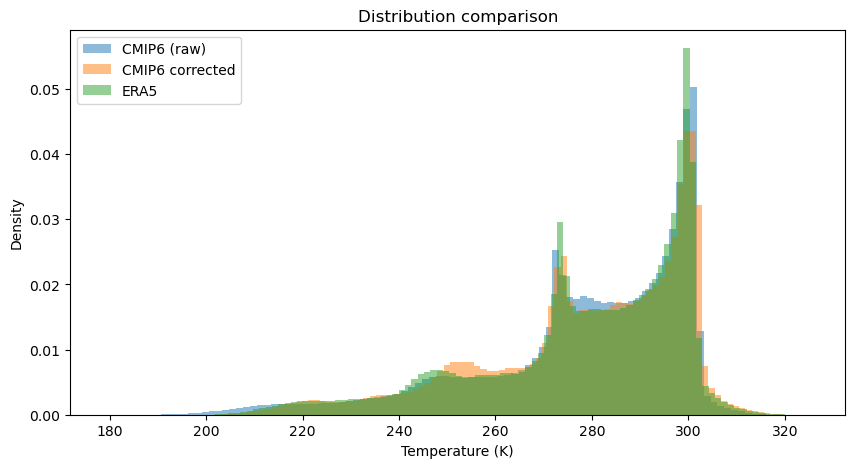

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(x, bins=100, alpha=0.5, label="CMIP6 (raw)", density=True)

plt.hist(x_corr, bins=100, alpha=0.5, label="CMIP6 corrected", density=True)

plt.hist(y, bins=100, alpha=0.5, label="ERA5", density=True)

plt.legend()
plt.title("Distribution comparison")
plt.xlabel("Temperature (K)")
plt.ylabel("Density")

plt.show()

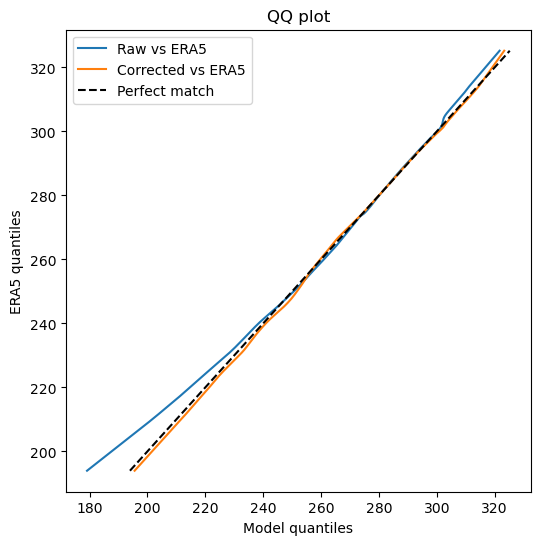

In [8]:
q = np.linspace(0, 1, 1000)

x_q = np.quantile(x, q)
xc_q = np.quantile(x_corr, q)
y_q = np.quantile(y, q)

plt.figure(figsize=(6, 6))

plt.plot(x_q, y_q, label="Raw vs ERA5")
plt.plot(xc_q, y_q, label="Corrected vs ERA5")

plt.plot(y_q, y_q, "k--", label="Perfect match")

plt.legend()

plt.xlabel("Model quantiles")
plt.ylabel("ERA5 quantiles")

plt.title("QQ plot")

plt.show()